In [46]:
import numpy as np
import numpy.linalg as la
from itertools import combinations
from scipy.linalg import toeplitz
from collections import Counter
################################################

from numpy import cos, sin, atan2,pi,exp
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, legend, show, xlabel, ylabel, title

In [ ]:
def theta(k,g):
    return atan2(sin(k),(g-cos(k)))

def aa(k,g):
    th = theta(k,g)
    return - cos(th/2)**2

def cc(k,g):
    th = theta(k,g)
    return sin(th/2)**2

def ac(k,g):
    th = theta(k,g)
    return 1j*cos(th/2)*sin(th/2)

def ca(k,g):
    th = theta(k,g)
    return -1j*cos(th/2)*sin(th/2)



def AA(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r)

    return -aa(k,g)*(phase-phase_i)

def CC(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r)
    return cc(k,g)*(phase-phase_i)

def AC(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r)
    return ac(k,g)*phase_i - ac(-k,g)*phase

def CA(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r) 
    return ca(k,g)*phase-ca(-k,g)*phase_i



In [1]:
import numpy as np
import numpy.linalg as la
from itertools import combinations
from scipy.linalg import toeplitz
from collections import Counter
################################################

from numpy import cos, sin, atan2,pi,exp
import matplotlib.pyplot as plt


In [227]:
# Definition of Theta
def theta(k,g):
    return atan2(sin(k),(g-cos(k)))

#The bogoliouv coefficients
def uv(k,g):
    t = theta(k,g)
    return cos(t/2), 1j*sin(t/2)

#Computations of <0| c_k c_-k |k, -k> 
def aa(k,g):
    u,v = uv(k,g)
    return -u*u
#Computations of <0| cdag_k cdag_-k |k, -k> 
def cc(k,g):
    u,v = uv(k,g)
    return v*np.conj(v)
#Computations of <0| c_k cdag_k |k, -k> 
def ac(k,g):
    u,v = uv(k,g)
    return u*v
#Computations of <0| cdag_k c_k |k, -k> 
def ca(k,g):
    u,v = uv(k,g)
    return -v*u


def AA(k,g,r):
    u,v = uv(k,g)
    phase = np.exp(1j*k*r)
    phase_inv = np.conj(phase)

    return u*np.conj(u)*(phase-phase_inv)

def CC(k,g,r):
    u,v = uv(k,g)
    phase = np.exp(1j*k*r)
    phase_inv = np.conj(phase)

    return v*np.conj(v)*(phase-phase_inv)

def AC(k,g,r):
    u,v = uv(k,g)
    phase = np.exp(1j*k*r)
    phase_inv = np.conj(phase)

    return u*v*(phase+phase_inv)
def CA(k,g,r):
    u,v = uv(k,g)
    phase = np.exp(1j*k*r)
    phase_inv = np.conj(phase)

    return -u*v*(phase+phase_inv)


def BA(k,g,r):
    args = (k,g,r)
    return -AC(*args)-AA(*args)+CC(*args)+CA(*args)


def AA_t(k,g,r):
    args = (k,g,r)
    return 0#AC(*args)+AA(*args)+CC(*args)+CA(*args)
def BB_t(k,g,r):
    args = (k,g,r)
    return 0#-(-AC(*args)+AA(*args)+CC(*args)-CA(*args))

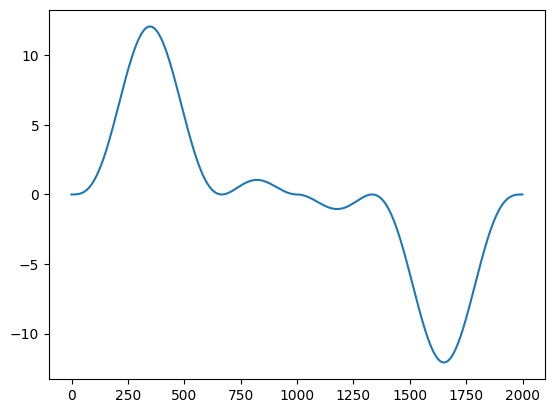

In [229]:
import numpy as np

# You already have:
# BA(k,g,r)
# AA_t(k,g,r)
# BB_t(k,g,r)

def pfaff(M):
    # simple O(n^3) Householder pfaffian – replace with your own if you have one
    M = np.array(M)
    n = M.shape[0]
    if n == 0:
        return 1.0
    if n == 2:
        return M[0,1]
    pf = 0.0
    for j in range(1,n):
        if M[0,j] != 0:
            sub = np.delete(np.delete(M, j, axis=0), 0, axis=0)
            sub = np.delete(np.delete(sub, j-1, axis=1), 0, axis=1)
            pf += ((-1)**(j+1)) * M[0,j] * pfaff(sub)
    return pf

import numpy as np

def pfaff(M):
    M = np.array(M)
    n = M.shape[0]
    if n == 0: return 1.0
    if n == 2: return M[0,1]
    pf = 0.0
    for j in range(1,n):
        if M[0,j] != 0:
            sub = np.delete(np.delete(M, j, axis=0), 0, axis=0)
            sub = np.delete(np.delete(sub, j-1, axis=1), 0, axis=1)
            pf += ((-1)**(j+1))*M[0,j]*pfaff(sub)
    return pf

def sigma_general(indices, g, k):
    #--- your duplicate-removal logic preserved
    def remove_duplicates_in_pairs(vec):
        unique_vals, counts = np.unique(vec, return_counts=True)
        filtered_vals = unique_vals[counts % 2 != 0]
        return filtered_vals.tolist()

    indices = np.sort(indices)
    indices = remove_duplicates_in_pairs(indices)

    # left endpoints = B’s, right endpoints = A’s
    odd_sites  = np.array(indices[::2])
    even_sites = np.array(indices[1::2])

    JW_string_lengths = even_sites - odd_sites
    N = np.sum(JW_string_lengths)

    # Fill full list of sites in all strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end   = indices[i+1]
        R.extend(range(start, end+1))

    # Your original coordinate extraction
    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]

    # Build full 2N x 2N Majorana correlation matrix
    Gamma = np.zeros((2*N, 2*N), dtype=complex)

    # Block BB
    for i in range(N):
        for j in range(N):
            r = B_coords[j] - B_coords[i]
            Gamma[i, j] = BB_t(k, g, r)

    # Block AA
    for i in range(N):
        for j in range(N):
            r = A_coords[j] - A_coords[i]
            Gamma[N+i, N+j] = AA_t(k, g, r)

    # Block BA and -BAᵀ
    for i in range(N):
        for j in range(N):
            r = A_coords[j] - B_coords[i]
            Gamma[i, N+j]     = BA(k, g, r)
            Gamma[N+j, i]     = -BA(k, g, r)

    # zero diagonals (Majorana requirement)
    np.fill_diagonal(Gamma, 0)

    return pfaff(Gamma)

plot(np.array([sigma_general([0,3],1,ki)for ki in k])/1j)

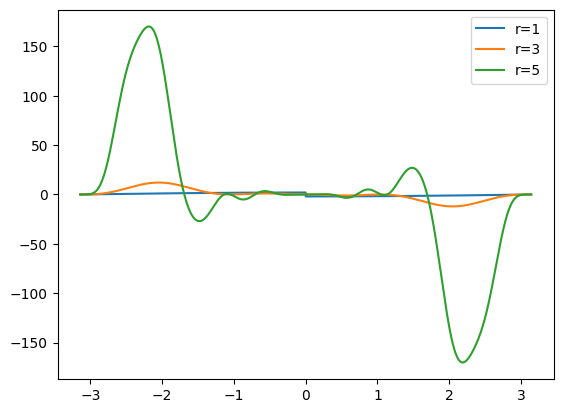

In [230]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

k = np.linspace(-np.pi, np.pi, 2000)

def eval_sigma(r):
    return np.array(
        Parallel(n_jobs=-1)(
            delayed(sigma_general)([0, r], 1, ki)
            for ki in k
        )
    ) / 1j

y01 = eval_sigma(1)
y03 = eval_sigma(3)
y05 = eval_sigma(5)

plt.plot(k, y01, label="r=1")
plt.plot(k, y03, label="r=3")
plt.plot(k, y05, label="r=5")
plt.legend()
plt.show()


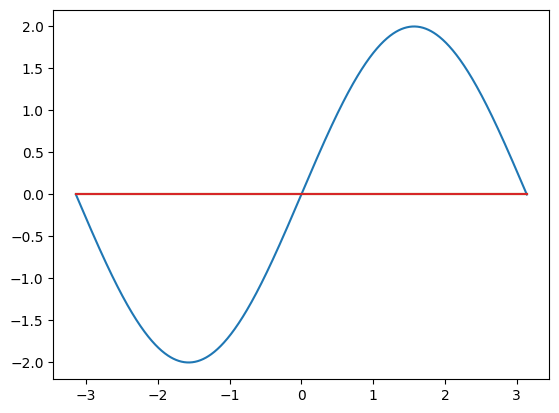

In [187]:
g= 100
r=1
plot(k,np.imag(AA_t(k,g,r)))
plot(k,np.real(AA_t(k,g,r)))

#plot(k,2*(sin(-k*r-theta(k,g))))

g= 1
r=0
plot(k,np.imag(AA_t(k,g,r)))
plot(k,np.real(AA_t(k,g,r)))

#plot(k,-2*(sin(k*r+theta(k,g))))

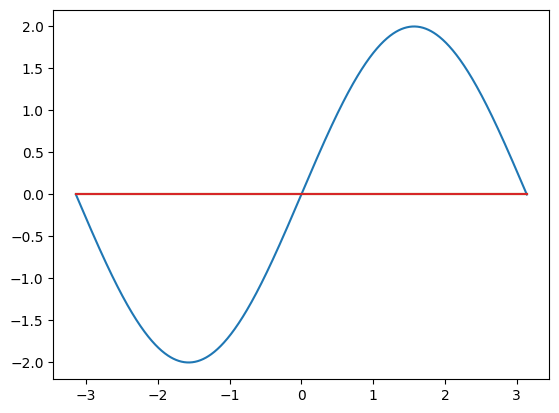

In [188]:
g= 13
r=1
plot(k,np.imag(BB_t(k,g,r)))
plot(k,np.real(BB_t(k,g,r)))

#plot(k,2*(sin(-k*r-theta(k,g))))

g= 1.1
r=0
plot(k,np.imag(BB_t(k,g,r)))
plot(k,np.real(BB_t(k,g,r)))

#plot(k,-2*(sin(k*r+theta(k,g))))

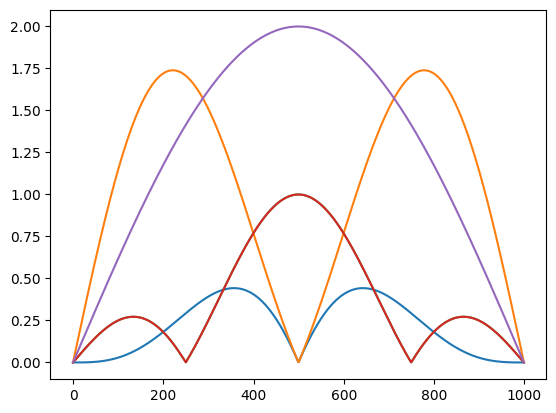

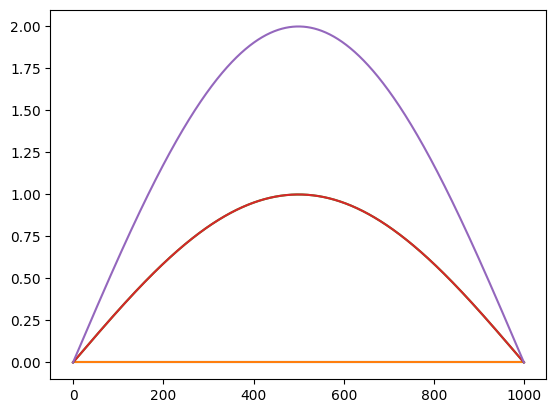

In [189]:
plt.plot(abs(CC(k,1,1)))
plt.plot(abs(AA(k,1,1)))
plt.plot(abs(CA(k,1,1)))
plt.plot(abs(AC(k,1,1)))
args = (k,1,1)

plt.plot(abs(CC(*args)-AA(*args)+CA(*args)-AC(*args)))
plt.show()
plt.plot(abs(CC(k,1,0)))
plt.plot(abs(AA(k,1,0)))
plt.plot(abs(CA(k,1,0)))
plt.plot(abs(AC(k,1,0)))
args = (k,1,0)
plt.plot(abs(CC(*args)-AA(*args)+CA(*args)-AC(*args)))


In [190]:

def sigma_general(indices,g,k):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = BA(k,g,1-Nd)
    return np.linalg.det(C)



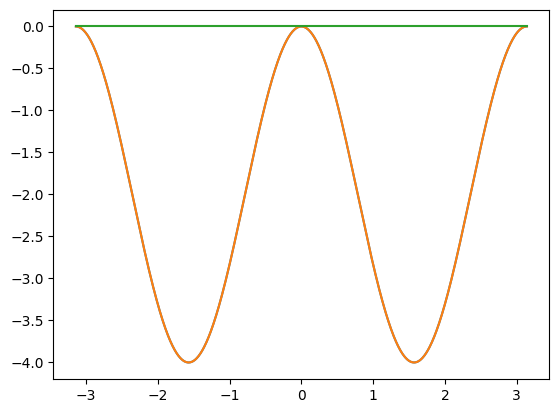

In [194]:
k = np.linspace(-pi,pi,1000)
g=1
z= np.array([ sigma_general([0,2],g,ki) for ki in k])
plot(k,-4*np.sin(k)*np.sin(k))

plot(k,np.real(z))
plot(k,np.imag(z))

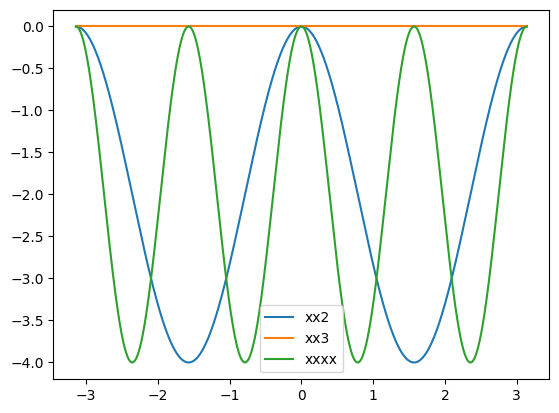

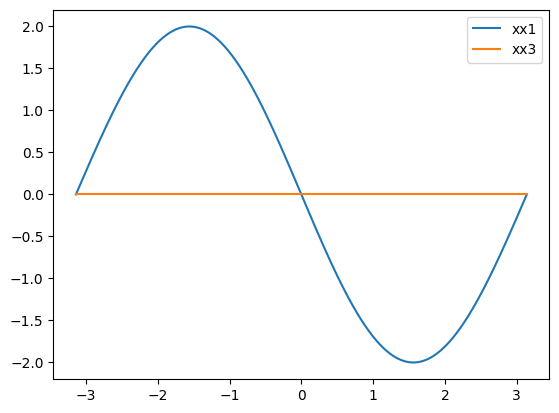

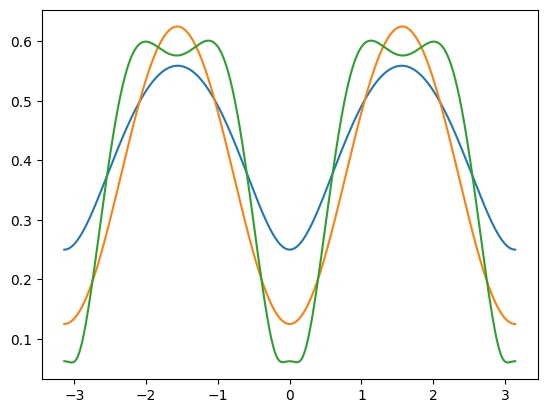

In [126]:
g = 100
x = np.array([ sigma_general([0,1],g,ki) for ki in k])
y =  np.array([ sigma_general([0,2],g,ki) for ki in k])
z= np.array([ sigma_general([0,6],g,ki) for ki in k])
w= np.array([ sigma_general([0,1,2,3],g,ki) for ki in k])

#plot(k,np.real(x),label= "xx1")
plot(k,np.real(y),label="xx2")
plot(k,np.real(z),label="xx3")
plot(k,np.real(w),label="xxxx")
legend()
show()
plot(k,np.imag(x),label= "xx1")
#plot(k,np.imag(y),label="xx2")
plot(k,np.imag(z),label="xx3")
#plot(k,np.imag(w),label="xxxx")
legend()
show()
x1 = (1+x)/4
x2 = (1+2*x+y)/8
x3 = (8*x2+y+x+z+w)/16

plt.plot(k,np.abs(x1))
plt.plot(k,np.abs(x2))
plt.plot(k,np.abs(x3))

In [70]:

################################################
#                X PROJECTORS
################################################

def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,g,k, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,g,k)))*degen)
        else:
            dat.append(sigma_general(indices,g,k)*degen)
   # dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n



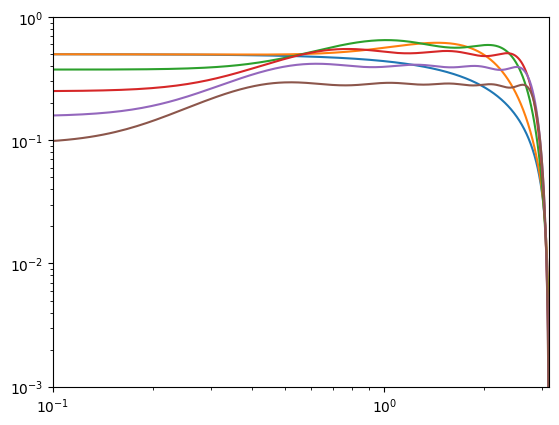

In [110]:
g= 1
plt.xlim(.1,pi)
plt.ylim(0.001,1)
plt.loglog()
plt.plot(k,np.array([np.abs(P_n(2,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(3,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(4,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(5,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(6,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(7,g,ki)) for ki in k]))

In [241]:
sigma_general([0,1],1,2)

np.complex128(-1.0806046117362795j)